Enter product to search on Snapdeal: Mobile
Product: Sb Grand Adjustable Mobile Holder for Smartphones and Tablets ( Black )
Price: 87.0
Rating: 76.0%
---
Product: THRIFTKART - 3 in 1 Fast Charging Cable,Portable 120W Charger Cord/Wire Compatible with iOS,Type-C,Micro Phones,Car/Travel 6A Retractable Zinc Alloy Charging Data Cable,Light Emitting Diode (Multicolor)
Price: 168.0
Rating: 76.0%
---
Product: Hybite Premium Selfie Stick, Blue tooth Extendable Selfie Stick Tri pod with Led Light Wireless Remote and Portable Tri pod Stand Compatible for All iPhone and Android Smartphone
Price: 265.0
Rating: 80.0%
---
Product: Shop To Shop Bluetooth Selfie Flash Light ( Black )
Price: 282.0
Rating: 82.0%
---
Product: HUG PUPPY Bluetooth Selfie Flash Light ( Black )
Price: 278.0
Rating: 82.0%
---
Product: 85W Fast Charger for Laptop, Tablet & Phone | Super-Fast Type-C Power Adapter | Universal High-Speed Charging with Smart Protection | Compact & Portable Wall Charger for Travel & Office"
Price:

C:\Users\admin\AppData\Local\Temp\ipykernel_47724\3406774538.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


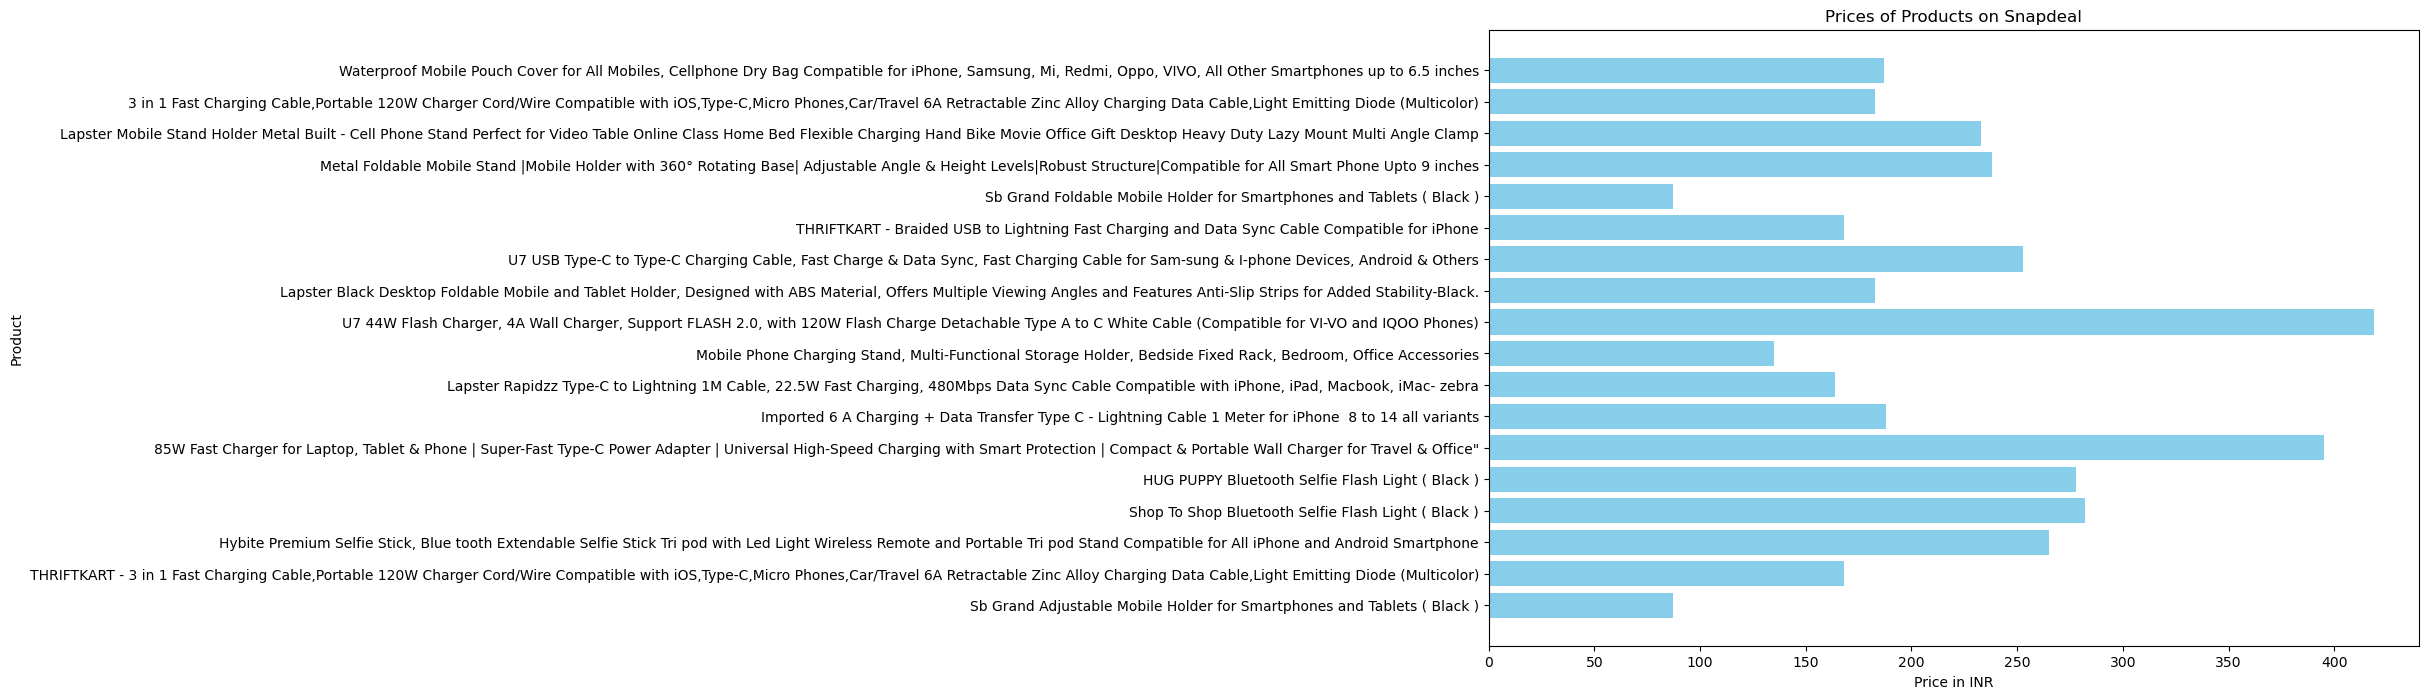

In [4]:
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import re

def convert_price_to_float(price_str):
    clean_price = re.sub(r'[^\d.]', '', price_str)  
    return float(clean_price) if clean_price else 0.0

def get_snapdeal_products(search_query):
    url = f'https://www.snapdeal.com/search?keyword={search_query.replace(" ", "%20")}'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/98.0.4758.102 Safari/537.36'
    }

    response = requests.get(url, headers=headers)
    products_data = []

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')
        products = soup.find_all('div', {'class': 'product-tuple-listing'})

        for product in products:
            title = product.find('p', {'class': 'product-title'})
            price = product.find('span', {'class': 'product-price'})
            if price:
                product_price = convert_price_to_float(price.get('data-price', '0'))
            else:
                product_price = 0.0 
            rating = product.find('div', {'class': 'filled-stars'})  

            if title and price:
                product_name = title.text.strip()
                #product_price = re.sub(r'[^\d.]', '', price.text.strip()) 
                product_rating = rating['style'].split(';')[0].split(':')[-1] if rating else "No rating"
                products_data.append({
                    'Product': product_name,
                    'Price': float(product_price),
                    'Rating': product_rating
                })
                print(f'Product: {product_name}')
                print(f'Price: {product_price}')
                print(f'Rating: {product_rating}')
                print('---')

    else:
        print('Failed to retrieve content')

    return products_data

if __name__ == "__main__":
    search_query = input('Enter product to search on Snapdeal: ')
    products = get_snapdeal_products(search_query)

def visualize_product_data(products):
    if products:
        
        product_names = [product['Product'] for product in products]
        product_prices = [product['Price'] for product in products]

        plt.figure(figsize=(12, 8))
        bars = plt.barh(product_names, product_prices, color='skyblue')  # Horizontal bar chart

        plt.xlabel('Price in INR')  
        plt.ylabel('Product')  
        plt.title(f'Prices of Products on Snapdeal')
        plt.tight_layout()
        plt.show()
    else:
        print('No products to display.')
visualize_product_data(products)
